In [68]:
import json
import numpy as np
from collections import defaultdict

# ✅ Path to your JSON file
file_path = "/Users/sagi/Data_Science/RA/xai-CheMLT-F/AttributionPipeline/data/clintox/integrated_gradients/train.json"

# --- Load data safely ---
with open(file_path, "r") as f:
    content = f.read().strip()

# Try both list-style and line-by-line JSONs
if content.startswith("["):
    data = json.loads(content)
else:
    data = [json.loads(line) for line in content.splitlines() if line.strip()]

print(f"✅ Loaded {len(data)} entries from {file_path}")

from collections import defaultdict

token_scores = defaultdict(list)

for entry in data:          # data = your loaded JSON list
    tokens = entry["tokens"]
    scores = entry["token_scores"]
    for t, s in zip(tokens, scores):
        if t not in ["[CLS]", "[SEP]"]:  # skip special tokens
            token_scores[t].append(s)




✅ Loaded 1184 entries from /Users/sagi/Data_Science/RA/xai-CheMLT-F/AttributionPipeline/data/clintox/integrated_gradients/train.json


In [69]:
data

[{'string': 'CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B(O)O',
  'tokens': ['CC',
   '(',
   'C',
   ')',
   'C',
   '[',
   'C',
   '@',
   'H',
   '](',
   'NC',
   '(=',
   'O',
   ')',
   'CNC',
   '(=',
   'O',
   ')',
   'c',
   '1',
   'cc',
   '(',
   'Cl',
   ')',
   'ccc',
   '1',
   'Cl',
   ')',
   'B',
   '(',
   'O',
   ')',
   'O'],
  'token_scores': [0.055091775953769684,
   0.09069257974624634,
   -0.0254482701420784,
   0.04203256964683533,
   -0.030711503699421883,
   -0.014476786367595196,
   -0.03406330943107605,
   0.08529837429523468,
   0.04078744351863861,
   0.1392333209514618,
   0.182756245136261,
   0.06838752329349518,
   -0.055049359798431396,
   -0.023014821112155914,
   0.4794727861881256,
   0.10408066213130951,
   -0.008680185303092003,
   0.021485311910510063,
   -0.04169781506061554,
   0.01840153895318508,
   0.02434016950428486,
   0.08921128511428833,
   -0.050195179879665375,
   0.08544575423002243,
   0.022566746920347214,
   0.028587734326720238

In [70]:
token_scores

defaultdict(list,
            {'CC': [0.055091775953769684,
              0.3692302703857422,
              0.3490472435951233,
              0.21717128157615662,
              0.06898099184036255,
              0.13261224329471588,
              0.1709214597940445,
              0.2801956534385681,
              0.1715012639760971,
              0.15129618346691132,
              0.22207732498645782,
              0.14881861209869385,
              0.22325843572616577,
              0.16096524894237518,
              0.15248404443264008,
              0.16685926914215088,
              0.14926253259181976,
              0.2656358480453491,
              0.056316256523132324,
              0.09151223301887512,
              0.0865146741271019,
              -0.0016183474799618125,
              0.18946564197540283,
              0.19088298082351685,
              0.18745394051074982,
              0.2039109319448471,
              0.24083887040615082,
              0.001348199555650353

In [71]:
print(f"Number of unique tokens: {len(token_scores)}")

Number of unique tokens: 336


In [72]:
# Collect all (token, score) pairs
token_score_pairs = []

for entry in data:
    tokens = entry.get("tokens", [])
    scores = entry.get("token_scores", [])
    for t, s in zip(tokens, scores):
        if t not in ["[CLS]", "[SEP]"]:
            token_score_pairs.append((t, s))

print(f"✅ Total pairs collected: {len(token_score_pairs)}")
print(token_score_pairs) 

✅ Total pairs collected: 47105
[('CC', 0.055091775953769684), ('(', 0.09069257974624634), ('C', -0.0254482701420784), (')', 0.04203256964683533), ('C', -0.030711503699421883), ('[', -0.014476786367595196), ('C', -0.03406330943107605), ('@', 0.08529837429523468), ('H', 0.04078744351863861), ('](', 0.1392333209514618), ('NC', 0.182756245136261), ('(=', 0.06838752329349518), ('O', -0.055049359798431396), (')', -0.023014821112155914), ('CNC', 0.4794727861881256), ('(=', 0.10408066213130951), ('O', -0.008680185303092003), (')', 0.021485311910510063), ('c', -0.04169781506061554), ('1', 0.01840153895318508), ('cc', 0.02434016950428486), ('(', 0.08921128511428833), ('Cl', -0.050195179879665375), (')', 0.08544575423002243), ('ccc', 0.022566746920347214), ('1', 0.028587734326720238), ('Cl', -0.14699901640415192), (')', 0.0750003308057785), ('B', 0.7735791206359863), ('(', 0.12131200730800629), ('O', -0.06529979407787323), (')', 0.05512607842683792), ('O', -0.03569262474775314), ('O', 0.059340994

In [73]:
import numpy as np
from collections import defaultdict

MIN_COUNT = 20
eps = 1e-12

# token_score_pairs = [(token, score), ...]

# --- Normalize ---
scores = np.asarray([s for _, s in token_score_pairs], dtype=float)
max_abs = np.max(np.abs(scores))

assert max_abs > 0, "All scores are zero — normalization meaningless"

token_score_pairs_norm = [
    (tok, s / max_abs) for tok, s in token_score_pairs
]

# --- Rebuild pipeline with normalized scores ---
token_scores = defaultdict(list)
for tok, s in token_score_pairs_norm:
    token_scores[tok].append(float(s))

vals_pos, vals_neg = defaultdict(list), defaultdict(list)
for tok, vals in token_scores.items():
    arr = np.asarray(vals)
    if np.any(arr > eps):
        vals_pos[tok] = arr[arr > eps].tolist()
    if np.any(arr < -eps):
        vals_neg[tok] = arr[arr < -eps].tolist()

def summarize(d):
    out = []
    for tok, vals in d.items():
        if len(vals) < MIN_COUNT:
            continue
        arr = np.asarray(vals, dtype=float)
        out.append((tok, arr.mean(), arr.std(), arr.size))
    return out

pos_stats = summarize(vals_pos)
neg_stats = summarize(vals_neg)
all_stats = summarize(token_scores)

activity_stats = []
for tok, vals in token_scores.items():
    if len(vals) < MIN_COUNT:
        continue
    arr = np.abs(np.asarray(vals))
    activity_stats.append((tok, arr.mean(), arr.std(), arr.size))

top5_pos = sorted(pos_stats, key=lambda x: x[1], reverse=True)[:5]
top5_neg = sorted(neg_stats, key=lambda x: x[1])[:5]
top5_neu = sorted(all_stats, key=lambda x: abs(x[1]))[:5]
most_active   = sorted(activity_stats, key=lambda x: x[1], reverse=True)[:5]
most_inactive = sorted(activity_stats, key=lambda x: x[1])[:5]


# 6) Pretty print
def pretty(title, rows):
    print(f"\n{title}")
    print("-"*len(title))
    for tok, mean, std, cnt in rows:
        print(f"{tok:16s} mean={mean: .4f}  std={std: .4f}  n={cnt}")

pretty("🔺 Top 5 Positive Tokens (mean on >0 scores)", top5_pos)
pretty("🔻 Top 5 Negative Tokens (mean on <0 scores)", top5_neg)
pretty("⚪ 5 Most Neutral Tokens (mean ≈ 0 on all scores)", top5_neu)
pretty("🔥 5 Most Active Tokens (highest mean |score|)", most_active)
pretty("❄️ 5 Most Inactive Tokens (lowest mean |score|)", most_inactive)



🔺 Top 5 Positive Tokens (mean on >0 scores)
-------------------------------------------
ncn              mean= 0.3669  std= 0.1977  n=22
CCCCC            mean= 0.2853  std= 0.1544  n=44
CCN              mean= 0.2703  std= 0.1612  n=58
+](=             mean= 0.2619  std= 0.1517  n=24
Nc               mean= 0.2560  std= 0.1753  n=105

🔻 Top 5 Negative Tokens (mean on <0 scores)
-------------------------------------------
-])              mean=-0.4112  std= 0.1810  n=265
-]               mean=-0.3976  std= 0.2124  n=125
NH               mean=-0.3570  std= 0.1914  n=467
+]               mean=-0.3466  std= 0.1772  n=212
-])[             mean=-0.3462  std= 0.1506  n=61

⚪ 5 Most Neutral Tokens (mean ≈ 0 on all scores)
------------------------------------------------
@@]              mean=-0.0003  std= 0.1245  n=161
COC              mean=-0.0011  std= 0.2170  n=60
Cl               mean= 0.0012  std= 0.1708  n=203
+])[             mean= 0.0023  std= 0.0633  n=23
5                mean= 0.0035 

In [8]:
import numpy as np

# ---- Inputs expected ----
# `data` must be a list of dicts, each like:
# {"tokens": [...], "scores": [...], "smiles": "...", ...}

SPECIAL = {"[CLS]", "[SEP]"}
EPS = 1e-12

# ---- Build extremes: for each token, track max/min score and ALL sequences where they occur ----
extremes = {}  # token -> {"max_score": float, "max_hits":[...], "min_score": float, "min_hits":[...]}

for seq_idx, entry in enumerate(data):
    tokens = entry.get("tokens", [])
    scores = entry.get("scores", [])
    smiles = entry.get("smiles", f"<no_smiles_{seq_idx}>")

    for tok_idx, (t, s) in enumerate(zip(tokens, scores)):
        if t in SPECIAL:
            continue
        s = float(s)
        rec = {
            "seq_idx": seq_idx,
            "tok_idx": tok_idx,
            "score": s,
            "smiles": smiles,
        }
        if t not in extremes:
            extremes[t] = {
                "max_score": s, "max_hits": [rec],
                "min_score": s, "min_hits": [rec],
            }
            continue

        # update MAX
        if s > extremes[t]["max_score"] + EPS:
            extremes[t]["max_score"] = s
            extremes[t]["max_hits"] = [rec]
        elif np.isclose(s, extremes[t]["max_score"], atol=EPS, rtol=0):
            extremes[t]["max_hits"].append(rec)

        # update MIN
        if s < extremes[t]["min_score"] - EPS:
            extremes[t]["min_score"] = s
            extremes[t]["min_hits"] = [rec]
        elif np.isclose(s, extremes[t]["min_score"], atol=EPS, rtol=0):
            extremes[t]["min_hits"].append(rec)

# ---- Compute global extremes across ALL tokens ----
global_max = {"token": None, "score": -np.inf, "hits": []}
global_min = {"token": None, "score":  np.inf, "hits": []}

for t, ex in extremes.items():
    smax = ex["max_score"]
    if smax > global_max["score"] + EPS:
        global_max = {"token": t, "score": smax, "hits": list(ex["max_hits"])}
    elif np.isclose(smax, global_max["score"], atol=EPS, rtol=0):
        global_max["hits"].extend(ex["max_hits"])

    smin = ex["min_score"]
    if smin < global_min["score"] - EPS:
        global_min = {"token": t, "score": smin, "hits": list(ex["min_hits"])}
    elif np.isclose(smin, global_min["score"], atol=EPS, rtol=0):
        global_min["hits"].extend(ex["min_hits"])

def show_global(ext, title="GLOBAL MAX", max_examples=5):
    if ext["token"] is None:
        print(f"{title}: <no data>")
        return
    print(f"\n{title}: token='{ext['token']}'  score={ext['score']:.6f}  (hits: {len(ext['hits'])})")
    for h in ext["hits"][:max_examples]:
        print(f"  • seq#{h['seq_idx']}  tok_idx={h['tok_idx']}  score={h['score']:.6f}")
        print(f"    SMILES: {h['smiles']}")
    if len(ext["hits"]) > max_examples:
        print(f"    ... and {len(ext['hits'])-max_examples} more")

show_global(global_max, "GLOBAL MAX")
show_global(global_min, "GLOBAL MIN")



GLOBAL MAX: token='CCCCCC'  score=0.989831  (hits: 1)
  • seq#168  tok_idx=1  score=0.989831
    SMILES: CCCCCC

GLOBAL MIN: token='NO'  score=-0.983700  (hits: 1)
  • seq#67  tok_idx=8  score=-0.983700
    SMILES: CC(Cc1ccccc1)NO


In [12]:
# Assume: data is your loaded JSON list of dicts with keys:
#  "tokens", "scores", "smiles" (and maybe "label", "method")
# Example element: data[i] = {"tokens":[...], "scores":[...], "smiles":"...", ...}

SPECIAL = {"[CLS]", "[SEP]"}
EPS = 1e-12  # tolerance for float equality

# For each token, track max/min score and ALL sequences where those scores occur
extremes = {}  # token -> {"max_score": float, "max_hits":[records...], "min_score": float, "min_hits":[records...]}

for seq_idx, entry in enumerate(data):
    tokens = entry.get("tokens", [])
    scores = entry.get("scores", [])
    smiles = entry.get("smiles", f"<no_smiles_{seq_idx}>")

    for tok_idx, (t, s) in enumerate(zip(tokens, scores)):
        if t in SPECIAL:
            continue
        rec = {
            "seq_idx": seq_idx,
            "tok_idx": tok_idx,
            "score": float(s),
            "smiles": smiles,
            # optionally include full token sequence; comment out if too large:
            # "tokens": tokens,
        }
        if t not in extremes:
            extremes[t] = {
                "max_score": float(s),
                "max_hits": [rec],
                "min_score": float(s),
                "min_hits": [rec],
            }
            continue

        # Update MAX
        if s > extremes[t]["max_score"] + EPS:
            extremes[t]["max_score"] = float(s)
            extremes[t]["max_hits"] = [rec]
        elif np.isclose(s, extremes[t]["max_score"], atol=EPS, rtol=0):
            extremes[t]["max_hits"].append(rec)

        # Update MIN
        if s < extremes[t]["min_score"] - EPS:
            extremes[t]["min_score"] = float(s)
            extremes[t]["min_hits"] = [rec]
        elif np.isclose(s, extremes[t]["min_score"], atol=EPS, rtol=0):
            extremes[t]["min_hits"].append(rec)

# ---------- Helpers to display results ----------
def show_token_extremes(token, max_examples=3, min_examples=3):
    if token not in extremes:
        print(f"Token '{token}' not found.")
        return
    ex = extremes[token]
    print(f"\nToken: {token}")
    print(f"  MAX score: {ex['max_score']:.6f}  (hits: {len(ex['max_hits'])})")
    for h in ex["max_hits"][:max_examples]:
        print(f"    • seq#{h['seq_idx']}  tok_idx={h['tok_idx']}  score={h['score']:.6f}")
        print(f"      SMILES: {h['smiles']}")
    if len(ex["max_hits"]) > max_examples:
        print(f"      ... and {len(ex['max_hits'])-max_examples} more")

    print(f"  MIN score: {ex['min_score']:.6f}  (hits: {len(ex['min_hits'])})")
    for h in ex["min_hits"][:min_examples]:
        print(f"    • seq#{h['seq_idx']}  tok_idx={h['tok_idx']}  score={h['score']:.6f}")
        print(f"      SMILES: {h['smiles']}")
    if len(ex["min_hits"]) > min_examples:
        print(f"      ... and {len(ex['min_hits'])-min_examples} more")

# Example: inspect a couple of tokens
show_token_extremes("+](")


Token '+](' not found.


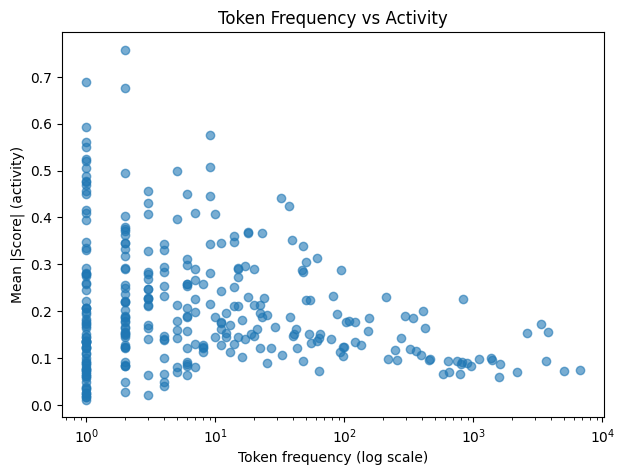

In [12]:
import matplotlib.pyplot as plt
import numpy as np
freq = {t: len(v) for t,v in token_scores.items()}
act = {t: np.mean(np.abs(v)) for t,v in token_scores.items()}

plt.figure(figsize=(7,5))
plt.scatter(list(freq.values()), list(act.values()), alpha=0.6)
plt.xscale('log')
plt.xlabel("Token frequency (log scale)")
plt.ylabel("Mean |Score| (activity)")
plt.title("Token Frequency vs Activity")
plt.show()
